# Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the CSV file
file_path='data'
#!ls '/content/drive/My Drive/SHAP'
df_processed_combined_data_daily = pd.read_csv(file_path+"/processed_combined_data_daily.csv")

df_processed_combined_data_daily.DateTime = pd.to_datetime(df_processed_combined_data_daily.DateTime)

In [2]:
df_processed_combined_data_daily.tail(2)

,DateTime,wind_speed,wind_direction,precipitation,pressure,temperature,humidity,visibility,cloudiness,Bjelave_PM10,...,Ilidža_O3,Vijećnica_PM10,Vijećnica_SO2,Vijećnica_NO2,Vijećnica_CO,Otoka_PM10,Otoka_SO2,Otoka_NO2,Otoka_O3,Ambasada_PM2.5
2177,2023-12-18,NaN,NaN,0.0,959.916667,0.320833,82.458333,19090.909091,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2178,2023-12-19,NaN,NaN,0.0,956.166667,-2.000000,96.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_processed_combined_data_daily['DateTime'] = pd.to_datetime(df_processed_combined_data_daily['DateTime'], dayfirst=True)
# Filter to keep only rows before 1.1.2024
df_processed_combined_data_daily = df_processed_combined_data_daily[df_processed_combined_data_daily['DateTime'] < '2023-01-01']

#  Data imputation with neighbors (processed_combined_imputed_with_neighbors_daily.csv)

In [4]:
columns = ['DateTime', 'wind_speed', 'wind_direction', 'precipitation', 'pressure', 'temperature', 'humidity', 'visibility', 'cloudiness', 'Bjelave_PM10', 'Bjelave_SO2', 'Bjelave_NO2']
df_processed_combined_data_daily = df_processed_combined_data_daily[columns]

In [5]:
def fill_missing_days_with_neighbors(df, label):
    df.set_index('DateTime', inplace=True)
    # counts number of consecutive missing values and stores start and end date of each sequence in a list
    nan_start_end_dates = df[df[label].isnull()].groupby(df[label].notnull().cumsum()).apply(lambda x: (x.index[0], x.index[-1])).tolist()
    for start_date, end_date in nan_start_end_dates:
        # Calculate the number of missing days between the start and end date +1 because we want to include the end date
        missing_days_number = (end_date - start_date).days + 1
        print(f"Filling missing values between {start_date} and {end_date} = number of missing days: {missing_days_number}")
        # take previous and next missing_days_number days grouped by day and calculate mean for each hour
        prev_days = df.loc[start_date - pd.DateOffset(days=missing_days_number) : start_date]
        next_days = df.loc[end_date : end_date + pd.DateOffset(days=missing_days_number)]
        neighbor_days = pd.concat([prev_days, next_days])
        mean_val = neighbor_days[label].mean()
        # fill missing days with mean values
        df.loc[start_date:end_date, label] = mean_val
    df.reset_index(inplace=True)
    return df

In [6]:
for column in df_processed_combined_data_daily.columns[1:]:  # Columns from index 1 to 14
    if df_processed_combined_data_daily[column].isnull().any():  # Check if there are missing values
        print(f"Processing column: {column}")
        df_processed_combined_data_daily = fill_missing_days_with_neighbors(df_processed_combined_data_daily, column)
    else:
        print(f"No missing values in column: {column}")

Processing column: wind_speed
Filling missing values between 2018-01-01 00:00:00 and 2018-12-31 00:00:00 = number of missing days: 365
Processing column: wind_direction
Filling missing values between 2018-01-01 00:00:00 and 2018-12-31 00:00:00 = number of missing days: 365
Filling missing values between 2021-11-24 00:00:00 and 2021-11-30 00:00:00 = number of missing days: 7
Processing column: precipitation
Filling missing values between 2018-09-04 00:00:00 and 2018-09-04 00:00:00 = number of missing days: 1
Filling missing values between 2018-09-08 00:00:00 and 2018-09-20 00:00:00 = number of missing days: 13
Processing column: pressure
Filling missing values between 2019-02-24 00:00:00 and 2019-02-24 00:00:00 = number of missing days: 1
No missing values in column: temperature
Processing column: humidity
Filling missing values between 2018-09-04 00:00:00 and 2018-09-04 00:00:00 = number of missing days: 1
Filling missing values between 2018-09-08 00:00:00 and 2018-09-20 00:00:00 = num

In [7]:
df_processed_combined_data_daily.to_csv('data/processed_combined_imputed_with_neighbors_df_processed_combined_data_daily.csv', index=False)

# Data visualisation

In [8]:
df_processed_combined_data_daily.tail(2)

,DateTime,wind_speed,wind_direction,precipitation,pressure,temperature,humidity,visibility,cloudiness,Bjelave_PM10,Bjelave_SO2,Bjelave_NO2
1824,2022-12-30,1.070833,159.541667,0.0,947.279167,6.429167,79.083333,19416.666667,4.000,67.841704,27.591008,54.974991
1825,2022-12-31,2.050000,128.875000,0.0,952.166667,6.670833,77.708333,18812.500000,2.775,48.536400,24.678667,32.047637


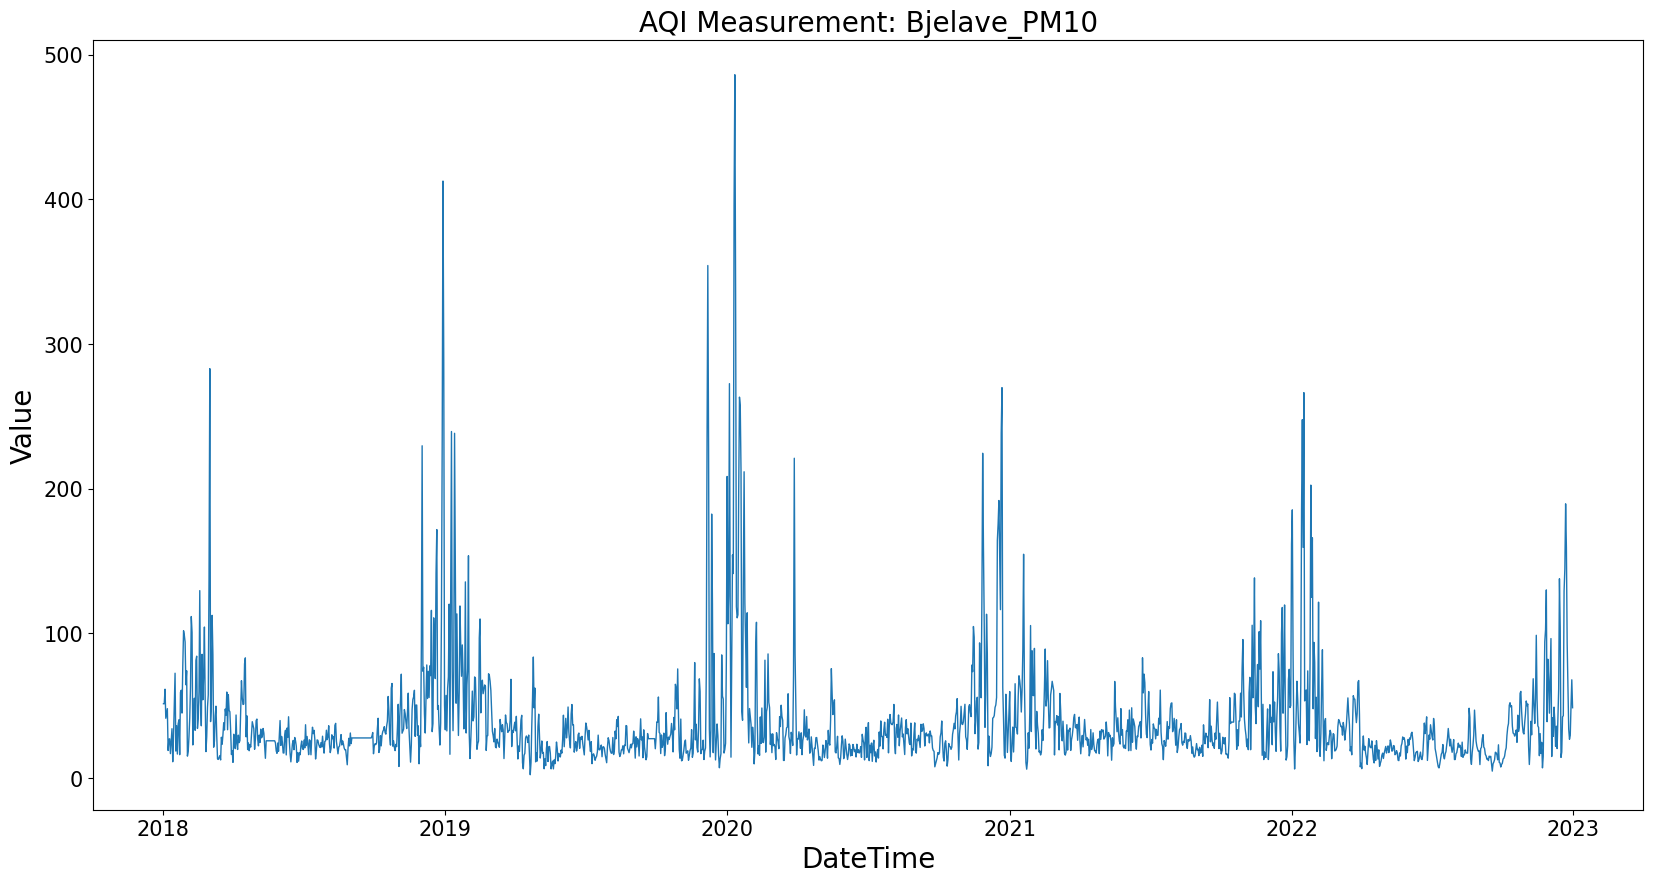

In [9]:
import matplotlib.pyplot as plt
#df_processed_combined_data_daily # Plot time seris data for columns, each with its own title
plt.figure(figsize=(20, 10))
plt.plot(df_processed_combined_data_daily['DateTime'], df_processed_combined_data_daily['Bjelave_PM10'], linewidth=1)

plt.xlabel('DateTime', fontsize=20)
plt.ylabel('Value', fontsize=20)
plt.title(f'AQI Measurement: Bjelave_PM10', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

In [10]:
def plot_forecast(test, forecast, date_col='ds', true_label='y', predicted_label='yhat'):
    plt.figure(figsize=(10,6))
    plt.plot(test[date_col], test[true_label], label='Actual')
    plt.plot(test[date_col], forecast[predicted_label], label='Predicted')
    plt.legend()
    plt.xlabel('Date')
    plt.ylabel(true_label)
    true_label='Bjelave_PM10'
    plt.title('Actual vs Predicted ' + true_label)
    plt.show()

# Dataset splitting

In [11]:
def train_test_split(df, date):
    df = df.copy()
    train_data = df[df['DateTime'] < date].copy()
    test_data = df[df['DateTime'] >= date].copy() # df.DateTime = df.DateTime.dt.strftime('%d/%m/%Y %H:%M')
    return train_data, test_data

def train_test_split_from_to(df, start_date, end_date, slice_date):
    df = df.copy()
    train_data = df[(df['DateTime'] >= start_date) & (df['DateTime'] < slice_date)].copy()
    test_data = df[(df['DateTime'] >= slice_date) & (df['DateTime'] <= end_date)].copy()
    return train_data, test_data

def plot_train_test_data(train_data, test_data, date_column, label):
    plt.figure(figsize=(20,10))
    plt.plot(train_data[date_column], train_data[label], color='blue', label='Train Data')
    plt.plot(test_data[date_column], test_data[label], color='orange', label='Test Data')
    plt.xlabel(date_column)
    plt.ylabel(label)
    plt.title(label + ' Train and Test Data')
    plt.legend()
    plt.show()

In [12]:
#input window = 30
date = df_processed_combined_data_daily['DateTime'].max() - pd.Timedelta(days=30)
train_data_combined_ws_thirty, test_data_combined_ws_thirty = train_test_split(df_processed_combined_data_daily, date)

#input window = 60
date = df_processed_combined_data_daily['DateTime'].max() - pd.Timedelta(days=60)
train_data_combined_ws_sixty, test_data_combined_ws_sixty = train_test_split(df_processed_combined_data_daily, date)

In [13]:
#input window = 90
date = df_processed_combined_data_daily['DateTime'].max() - pd.Timedelta(days=90)
train_data_combined_ws_ninety, test_data_combined_ws_ninety = train_test_split(df_processed_combined_data_daily, date) #

#input window = 180
date = df_processed_combined_data_daily['DateTime'].max() - pd.Timedelta(days=180)
train_data_combined_ws_oneHundredEighty, test_data_combined_ws_oneHundredEighty = train_test_split(df_processed_combined_data_daily, date) #

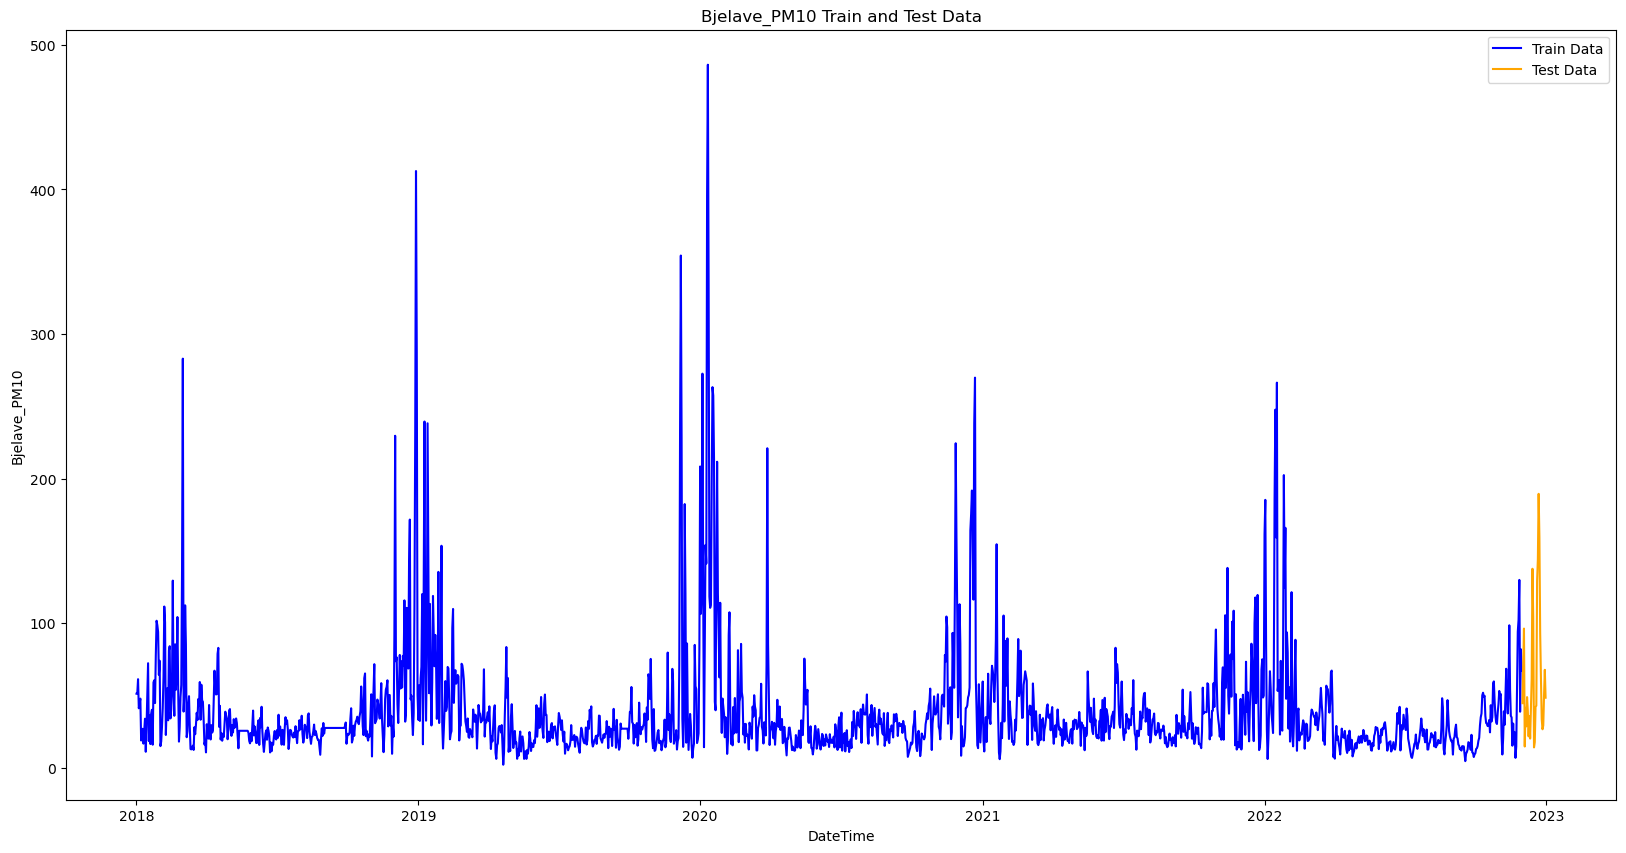

In [14]:
plot_train_test_data(train_data_combined_ws_thirty, test_data_combined_ws_thirty, 'DateTime', 'Bjelave_PM10')

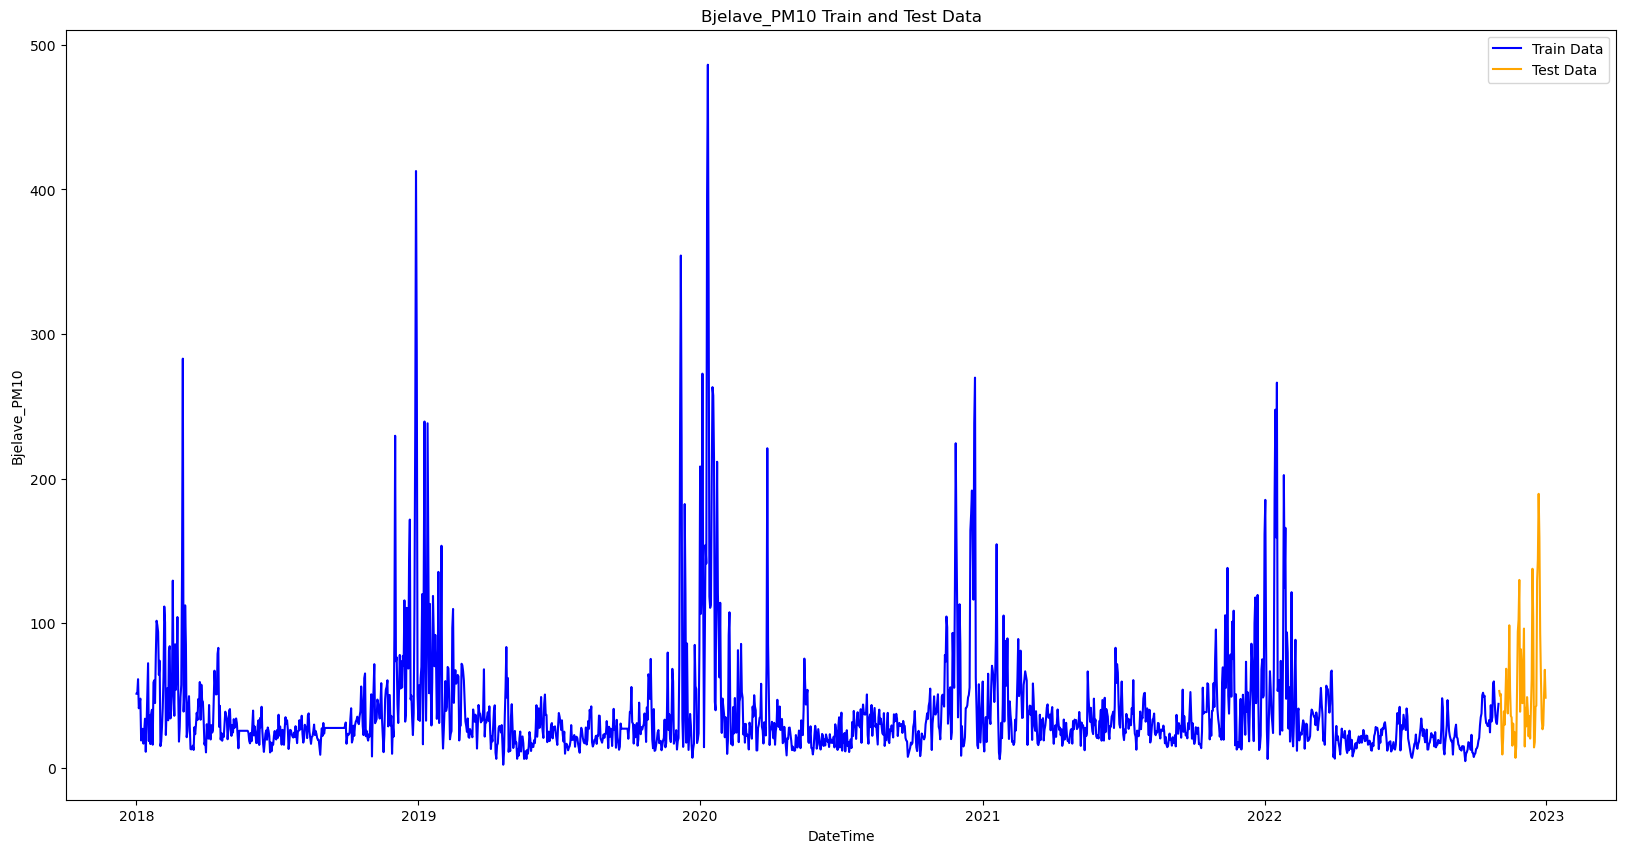

In [15]:
plot_train_test_data(train_data_combined_ws_sixty, test_data_combined_ws_sixty, 'DateTime', 'Bjelave_PM10')

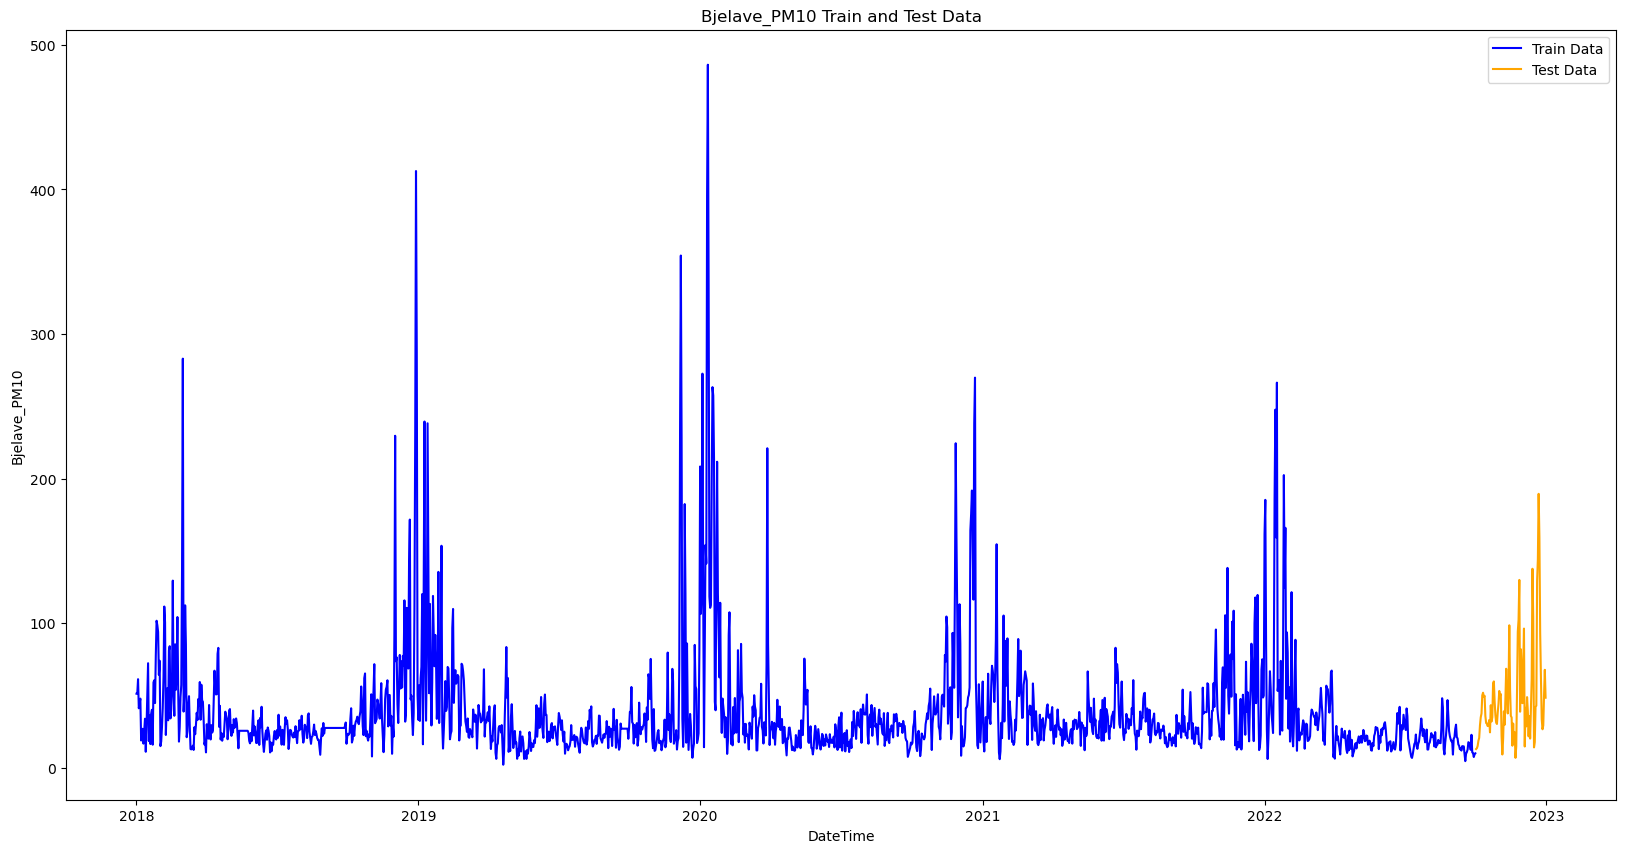

In [16]:
plot_train_test_data(train_data_combined_ws_ninety, test_data_combined_ws_ninety, 'DateTime', 'Bjelave_PM10')

# Multivariate Time Series Forecasting using FBProphet

In [17]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

/opt/anaconda3/envs/shap_for_ts_prediction/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
train_data_combined_ws_thirty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)
test_data_combined_ws_thirty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)

train_data_combined_ws_sixty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)
test_data_combined_ws_sixty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)

In [19]:
train_data_combined_ws_ninety.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)
test_data_combined_ws_ninety.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)

train_data_combined_ws_oneHundredEighty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)
test_data_combined_ws_oneHundredEighty.rename(columns={'DateTime': 'ds', 'Bjelave_PM10': 'y'}, inplace=True)

In [20]:
def train_prophet_multivariate(train_data):
    model = Prophet()
    #added
    model.add_regressor('wind_speed')
    model.add_regressor('wind_direction')
    model.add_regressor('precipitation')
    model.add_regressor('pressure')
    model.add_regressor('temperature')
    model.add_regressor('humidity')
    model.add_regressor('visibility')
    model.add_regressor('cloudiness') #model.add_regressor('Bjelave_PM10')
    model.add_regressor('Bjelave_SO2')
    model.add_regressor('Bjelave_NO2')
    #added
    model.fit(train_data)
    return model
def predict_prophet(model, test_data):
    forecast = model.predict(test_data)
    return forecast

def calculate_metrics(test, forecast, true_label='y', predicted_label='yhat'):
    mae = mean_absolute_error(test[true_label], forecast[predicted_label])
    mse = mean_squared_error(test[true_label], forecast[predicted_label])
    rmse = sqrt(mse)
    r2 = r2_score(test[true_label], forecast[predicted_label])
    return rmse, mae, r2

def plot_boxplot(prediction_data, test_data):
    error = abs(prediction_data - test_data)
    # plot boxplot of error
    plt.figure(figsize=(10,6))
    plt.boxplot(error)
    plt.show()

In [21]:
model_combined_ws_thirty = train_prophet_multivariate(train_data_combined_ws_thirty)
forecast_combined_ws_thirty = predict_prophet(model_combined_ws_thirty, test_data_combined_ws_thirty)
rmse, mae, r2 = calculate_metrics(test_data_combined_ws_thirty, forecast_combined_ws_thirty)

print('RMSE: %.3f' % rmse)
print('MAE: %.3f' % mae)
print('R2: %.3f' % r2)

12:22:25 - cmdstanpy - INFO - Chain [1] start processing
12:22:26 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 27.266
MAE: 23.778
R2: 0.642


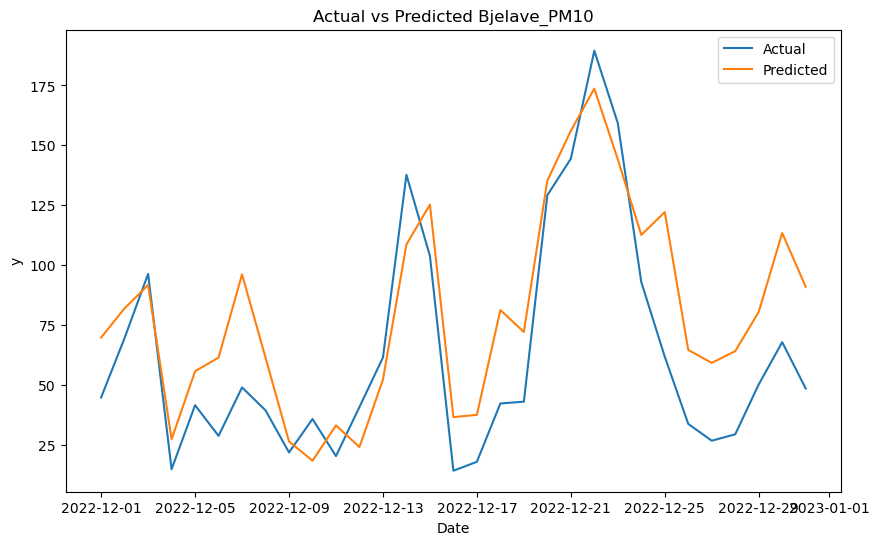

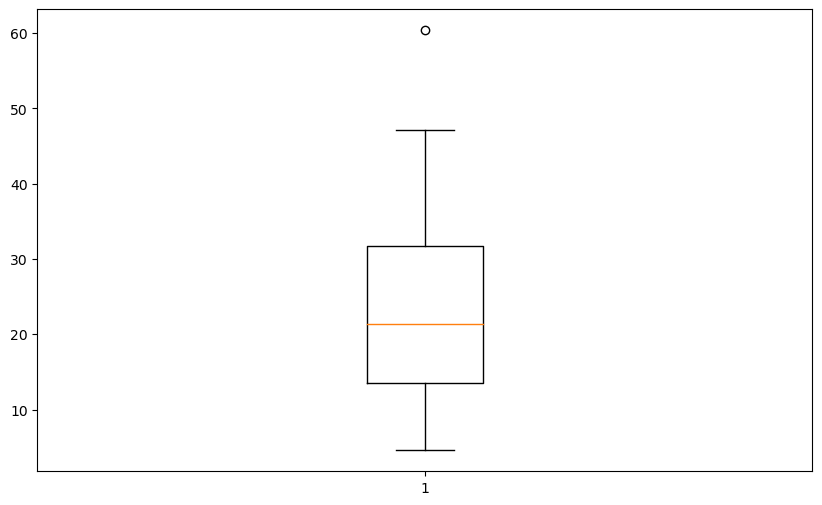

In [22]:
plot_forecast(test_data_combined_ws_thirty, forecast_combined_ws_thirty)
plot_boxplot(forecast_combined_ws_thirty['yhat'].values.reshape(-1,1), test_data_combined_ws_thirty['y'].values.reshape(-1,1))

In [23]:
model_combined_ws_sixty = train_prophet_multivariate(train_data_combined_ws_sixty)
forecast_combined_ws_sixty = predict_prophet(model_combined_ws_sixty, test_data_combined_ws_sixty)
rmse, mae, r2 = calculate_metrics(test_data_combined_ws_sixty, forecast_combined_ws_sixty)

print('RMSE: %.3f' % rmse)
print('MAE: %.3f' % mae)
print('R2: %.3f' % r2)

12:22:27 - cmdstanpy - INFO - Chain [1] start processing
12:22:27 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 23.206
MAE: 19.322
R2: 0.650


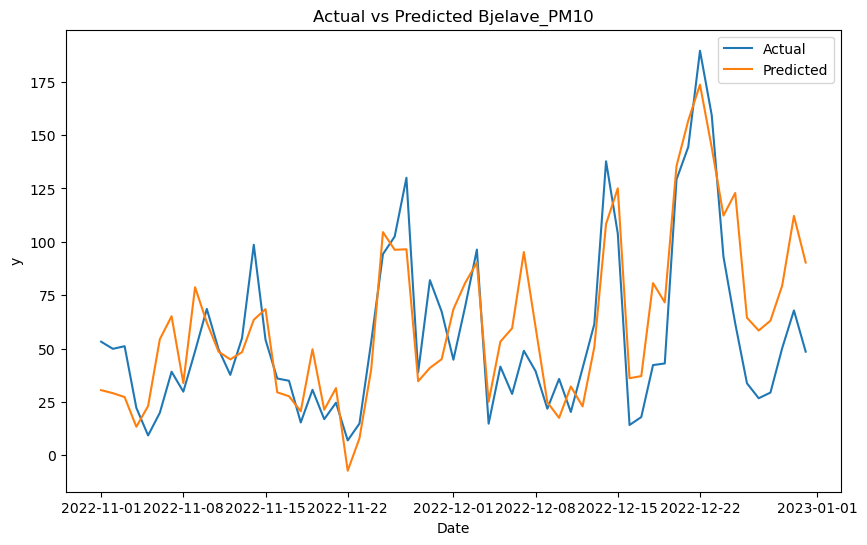

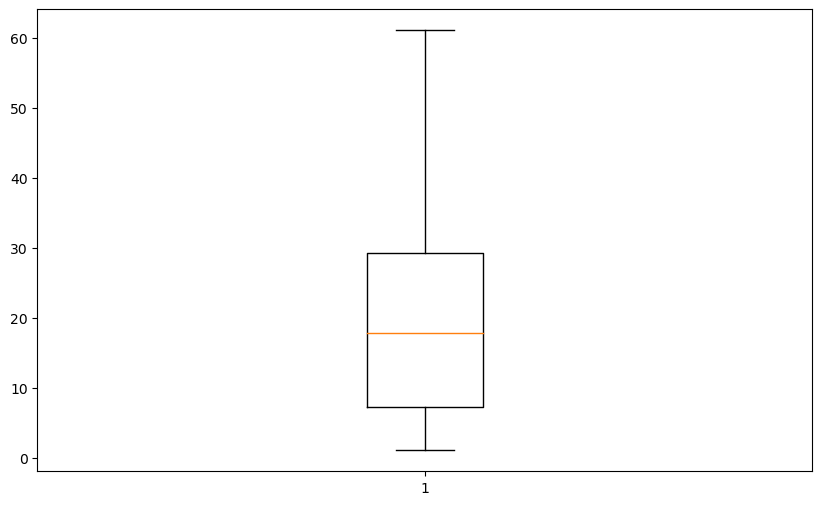

In [24]:
plot_forecast(test_data_combined_ws_sixty, forecast_combined_ws_sixty)
plot_boxplot(forecast_combined_ws_sixty['yhat'].values.reshape(-1,1), test_data_combined_ws_sixty['y'].values.reshape(-1,1))

In [25]:
model_combined_ws_ninety = train_prophet_multivariate(train_data_combined_ws_ninety)
forecast_combined_ws_ninety = predict_prophet(model_combined_ws_ninety, test_data_combined_ws_ninety)
rmse, mae, r2 = calculate_metrics(test_data_combined_ws_ninety, forecast_combined_ws_ninety)

print('RMSE: %.3f' % rmse)
print('MAE: %.3f' % mae)
print('R2: %.3f' % r2)

12:22:28 - cmdstanpy - INFO - Chain [1] start processing
12:22:29 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 19.723
MAE: 15.692
R2: 0.669


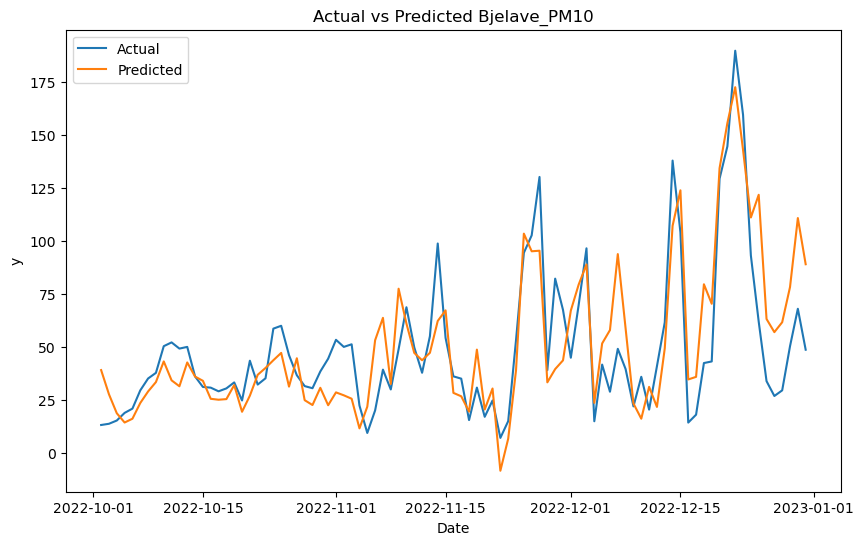

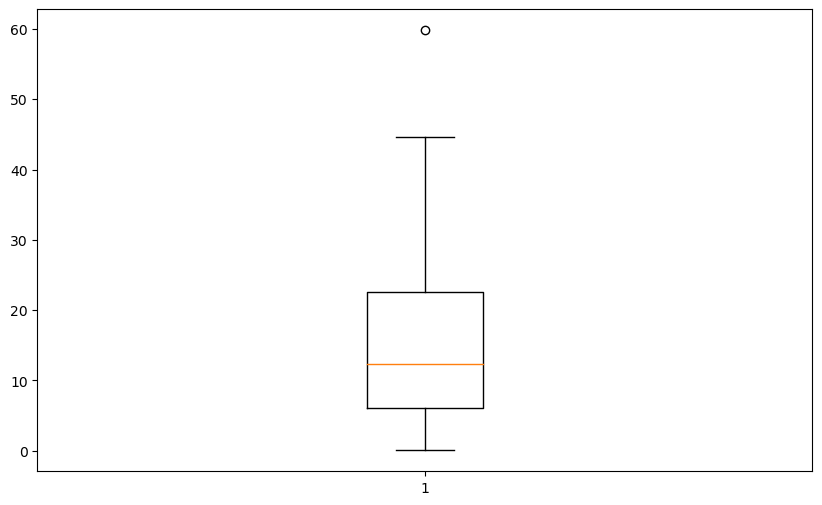

In [26]:
plot_forecast(test_data_combined_ws_ninety, forecast_combined_ws_ninety)
plot_boxplot(forecast_combined_ws_ninety['yhat'].values.reshape(-1,1), test_data_combined_ws_ninety['y'].values.reshape(-1,1))

In [27]:
model_combined_ws_oneHundredEighty = train_prophet_multivariate(train_data_combined_ws_oneHundredEighty)
forecast_combined_ws_oneHundredEighty = predict_prophet(model_combined_ws_oneHundredEighty, test_data_combined_ws_oneHundredEighty)
rmse, mae, r2 = calculate_metrics(test_data_combined_ws_oneHundredEighty, forecast_combined_ws_oneHundredEighty)

print('RMSE: %.3f' % rmse)
print('MAE: %.3f' % mae)
print('R2: %.3f' % r2)

12:22:30 - cmdstanpy - INFO - Chain [1] start processing
12:22:31 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 17.286
MAE: 13.057
R2: 0.648


# Prerequisites and Data Preparation for SHAP Analysis of Facebook Prophet Models


In [36]:
def prophet_predict_ws_thirty_for_shap_combined(data_df):
    if not isinstance(data_df, pd.DataFrame):
         data_df = pd.DataFrame(data_df, columns=feature_columns_combined)
    predictions = model_combined_ws_thirty.predict(data_df)
    return predictions['yhat'].values

def prophet_predict_ws_sixty_for_shap_combined(data_df):
    if not isinstance(data_df, pd.DataFrame):
         data_df = pd.DataFrame(data_df, columns=feature_columns_combined)
    predictions = model_combined_ws_sixty.predict(data_df)
    return predictions['yhat'].values


def prophet_predict_ws_ninety_for_shap_combined(data_df):
    if not isinstance(data_df, pd.DataFrame):
         data_df = pd.DataFrame(data_df, columns=feature_columns_combined)
    predictions = model_combined_ws_ninety.predict(data_df)
    return predictions['yhat'].values

def prophet_predict_ws_oneHundredEighty_for_shap_combined(data_df):
    if not isinstance(data_df, pd.DataFrame):
         data_df = pd.DataFrame(data_df, columns=feature_columns_combined)
    predictions = model_combined_ws_oneHundredEighty.predict(data_df)
    return predictions['yhat'].values

In [37]:
feature_columns_combined=['ds', 'y','wind_speed','wind_direction','precipitation','pressure', 'temperature','humidity','visibility','cloudiness','Bjelave_SO2','Bjelave_NO2']
feature_columns_aqi=['ds','y']

In [38]:
import shap
#backgraound data je citav dataset
#testirano na 100 uzoraka inace (samo ws 30 i 60)
background_data_combined_ws_thirty = shap.sample(train_data_combined_ws_thirty, 100)
background_data_combined_ws_sixty= shap.sample(train_data_combined_ws_sixty, 100)
background_data_combined_ws_ninety = shap.sample(train_data_combined_ws_ninety, 100)

In [39]:
data_combined_to_explain_ws_thirty=test_data_combined_ws_thirty.rename(columns={'y': 'yhat'})
data_combined_to_explain_ws_sixty=test_data_combined_ws_sixty.rename(columns={'y': 'yhat'})
data_combined_to_explain_ws_ninety=test_data_combined_ws_ninety.rename(columns={'y': 'yhat'})

In [69]:
day20_to_explain_ws_thirty = data_combined_to_explain_ws_thirty.iloc[[19]]
day30_to_explain_ws_thirty = data_combined_to_explain_ws_thirty.iloc[[29]]

In [95]:
day20_to_explain_ws_thirty

,ds,wind_speed,wind_direction,precipitation,pressure,temperature,humidity,visibility,cloudiness,yhat,Bjelave_SO2,Bjelave_NO2
1814,2022-12-20,0.7,207.416667,0.0,951.8,-0.829167,96.583333,3196.666667,7.016667,129.1965,30.669217,48.330933


In [96]:
day30_to_explain_ws_thirty

,ds,wind_speed,wind_direction,precipitation,pressure,temperature,humidity,visibility,cloudiness,yhat,Bjelave_SO2,Bjelave_NO2
1824,2022-12-30,1.070833,159.541667,0.0,947.279167,6.429167,79.083333,19416.666667,4.0,67.841704,27.591008,54.974991


In [92]:
type(data_combined_to_explain_ws_thirty)

pandas.core.frame.DataFrame

In [116]:
day45_to_explain_ws_sixty = data_combined_to_explain_ws_sixty.iloc[[44]]
day55_to_explain_ws_sixty = data_combined_to_explain_ws_sixty.iloc[[54]]
day60_to_explain_ws_sixty = data_combined_to_explain_ws_sixty.iloc[[59]]

In [117]:
day45_to_explain_ws_sixty

,ds,wind_speed,wind_direction,precipitation,pressure,temperature,humidity,visibility,cloudiness,yhat,Bjelave_SO2,Bjelave_NO2
1809,2022-12-15,1.179167,159.041667,0.008333,932.758333,5.079167,94.125,7640.0,6.270833,103.846267,26.015179,48.084808


In [43]:
print("len(data_combined_to_explain_ws_thirty)", len(data_combined_to_explain_ws_thirty))
print("len(data_combined_to_explain_ws_sixty)", len(data_combined_to_explain_ws_sixty))
print("len(data_combined_to_explain_ws_ninety)", len(data_combined_to_explain_ws_ninety))


len(data_combined_to_explain_ws_thirty) 31
len(data_combined_to_explain_ws_sixty) 61
len(data_combined_to_explain_ws_ninety) 91


# SHAP Analysis of Selected Forecast Horizons in Facebook Prophet Model [WINDOW SIZE=30]


In [54]:
custom_feature_names = [
    'Bjelave_PM10' if col == 'yhat' else
    'DateTime' if col == 'ds' else
    col
    for col in data_combined_to_explain_ws_thirty.columns
]

In [55]:
custom_feature_names


['DateTime',
 'wind_speed',
 'wind_direction',
 'precipitation',
 'pressure',
 'temperature',
 'humidity',
 'visibility',
 'cloudiness',
 'Bjelave_PM10',
 'Bjelave_SO2',
 'Bjelave_NO2']

In [ ]:
explainer_data_combined_ws_thirty = shap.KernelExplainer(prophet_predict_ws_thirty_for_shap_combined, background_data_combined_ws_thirty)
shap_values_data_combined_ws_thirty = explainer_data_combined_ws_thirty.shap_values(data_combined_to_explain_ws_thirty)

  0%|          | 0/31 [00:00<?, ?it/s]

In [ ]:
explainer_data_combined_ws_thirty_mod = shap.Explanation(
    values=shap_values_data_combined_ws_thirty,
    base_values=np.array([explainer_data_combined_ws_thirty.expected_value] * len(shap_values_data_combined_ws_thirty)),
    data=data_combined_to_explain_ws_thirty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_thirty_mod, max_display=len(custom_feature_names))

In [ ]:
explainer_data_combined_ws_thirty_mod = shap.Explanation(
    values=shap_values_data_combined_ws_thirty,
    base_values=np.array([explainer_data_combined_ws_thirty.expected_value] * len(shap_values_data_combined_ws_thirty)),
    data=data_combined_to_explain_ws_thirty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_thirty_mod, max_display=len(custom_feature_names))

In [ ]:
shap.plots.beeswarm(explainer_data_combined_ws_thirty_mod, max_display=len(custom_feature_names))

# SHAP Analysis of Selected Prediction Days in Facebook Prophet Model [WINDOW SIZE=60]


In [75]:
explainer_day_combined_ws_sixty = shap.KernelExplainer(prophet_predict_ws_sixty_for_shap_combined, background_data_combined_ws_sixty)

In [135]:
print("explainer_day_combined_ws_sixty.expected_value: ", explainer_day_combined_ws_sixty.expected_value)

explainer_day_combined_ws_sixty.expected_value:  -19772.518571074746


In [136]:
shap_values_day20_combined_ws_sixty = explainer_day_combined_ws_sixty.shap_values(day20_to_explain_ws_thirty)

  0%|          | 0/1 [00:06<?, ?it/s]


KeyboardInterrupt: 

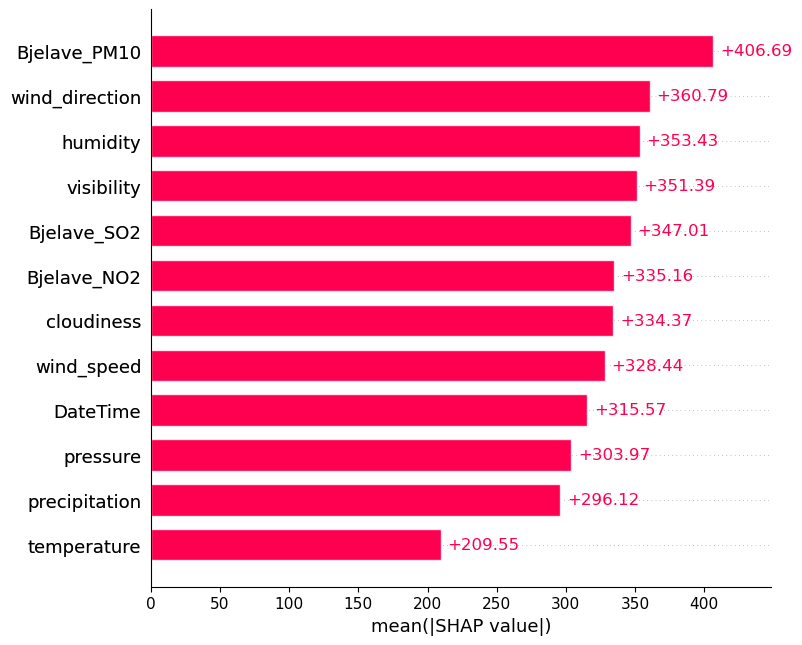

In [77]:
explainer_day20_combined_ws_sixty = shap.Explanation(
    values=shap_values_day20_combined_ws_sixty,
    base_values=np.array([explainer_day_combined_ws_sixty.expected_value] * len(shap_values_day20_combined_ws_sixty)),
    data=day20_to_explain_ws_thirty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_day20_combined_ws_sixty, max_display=len(custom_feature_names))

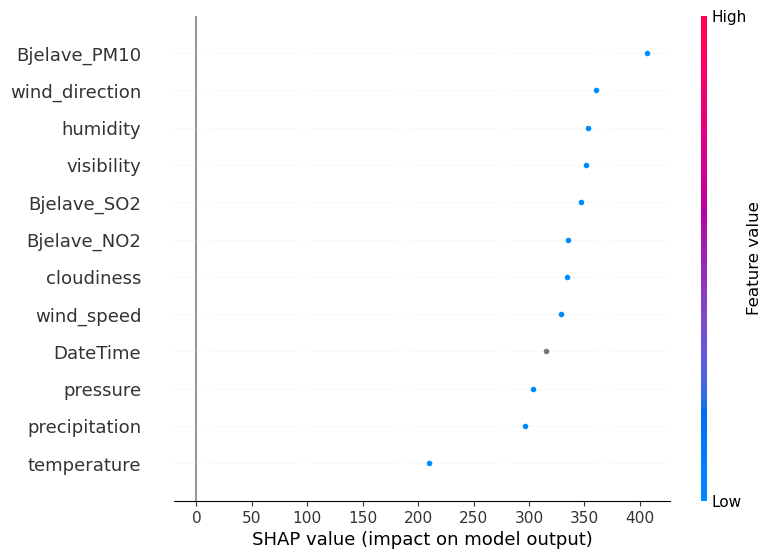

In [156]:
shap.plots.beeswarm(explainer_day20_combined_ws_sixty, max_display=len(custom_feature_names))


In [104]:
print(shap_values_day20_combined_ws_sixty)


[[315.56509777 328.43676581 360.79237635 296.12222053 303.97466767
  209.54572604 353.43462918 351.38979541 334.36525723 406.69309211
  347.01269487 335.15684631]]


In [109]:
print(shap_values_day30_combined_ws_sixty)

[[ -72.60333177  -67.46288048  -69.07901515  -74.4647574   -70.71585284
  -120.03739882  -44.32235247   25.81156395  -71.97317514  -92.13347667
   -37.76783218  -73.53120764]]


In [106]:
shap_values_day30_combined_ws_sixty = explainer_day_combined_ws_sixty.shap_values(day30_to_explain_ws_thirty)

100%|██████████| 1/1 [06:16<00:00, 376.27s/it]


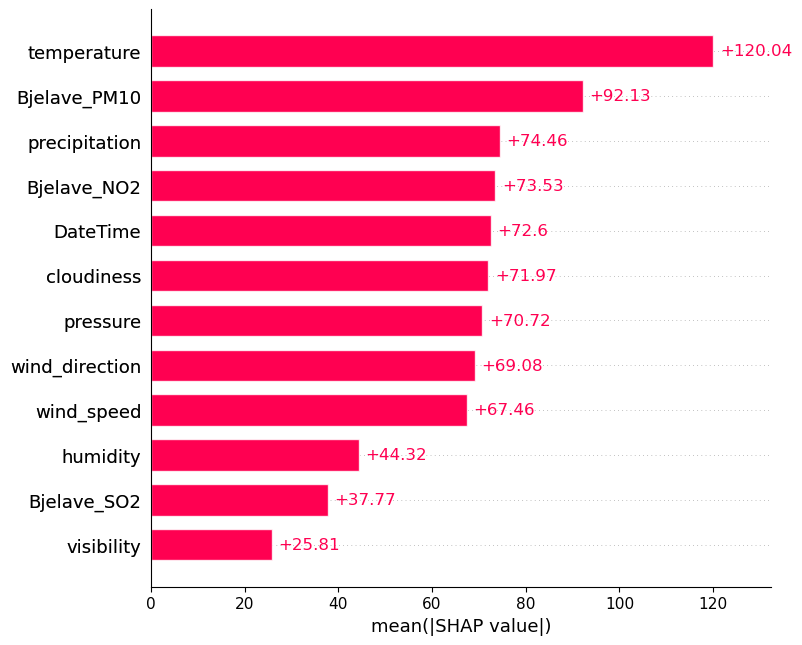

In [108]:
explainer_day30_combined_ws_sixty = shap.Explanation(
    values=shap_values_day30_combined_ws_sixty,
    base_values=np.array([explainer_day_combined_ws_sixty.expected_value] * len(shap_values_day30_combined_ws_sixty)),
    data=day30_to_explain_ws_thirty.values,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_day30_combined_ws_sixty, max_display=len(custom_feature_names))

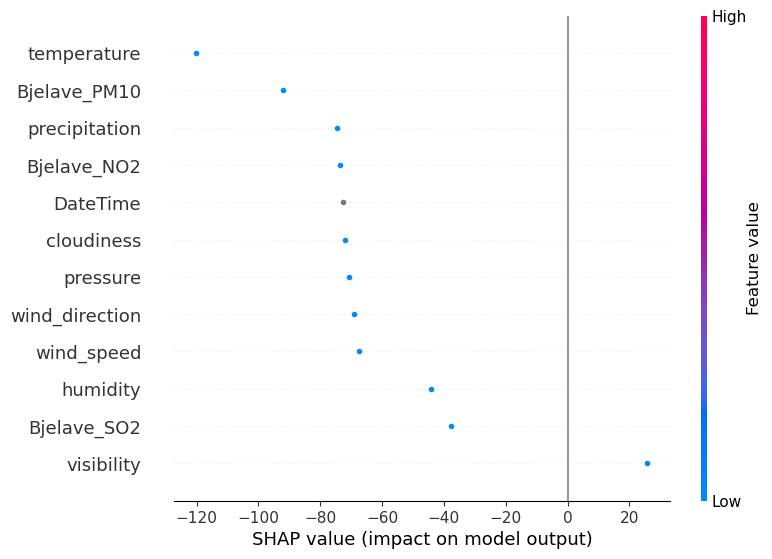

In [157]:
shap.plots.beeswarm(explainer_day30_combined_ws_sixty, max_display=len(custom_feature_names))


In [140]:
shap_values_day45_combined_ws_sixty = explainer_day_combined_ws_sixty.shap_values(day45_to_explain_ws_sixty)


100%|██████████| 1/1 [04:22<00:00, 262.19s/it]


In [141]:
print(day45_to_explain_ws_sixty.shape)  # treba biti (1, 12)
print(np.array(shap_values_day45_combined_ws_sixty).shape)

(1, 12)
(1, 12)


In [142]:
print(shap_values_day45_combined_ws_sixty)

[[266.95358409 239.18152305 279.7969199  304.25267069 278.26052805
  190.864665   317.69523409 266.18359041 244.16699162 250.82992769
  292.38486713 317.20959138]]


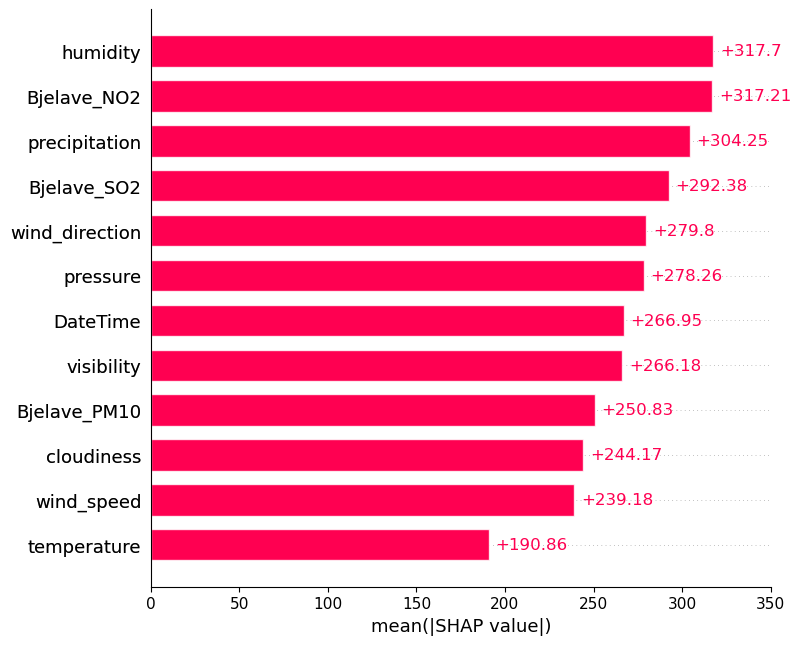

In [144]:
explainer_day45_combined_ws_sixty = shap.Explanation(
    values=shap_values_day45_combined_ws_sixty,
    base_values=np.array([explainer_day_combined_ws_sixty.expected_value] * len(shap_values_day45_combined_ws_sixty)),
    data=shap_values_day45_combined_ws_sixty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_day45_combined_ws_sixty, max_display=len(custom_feature_names))

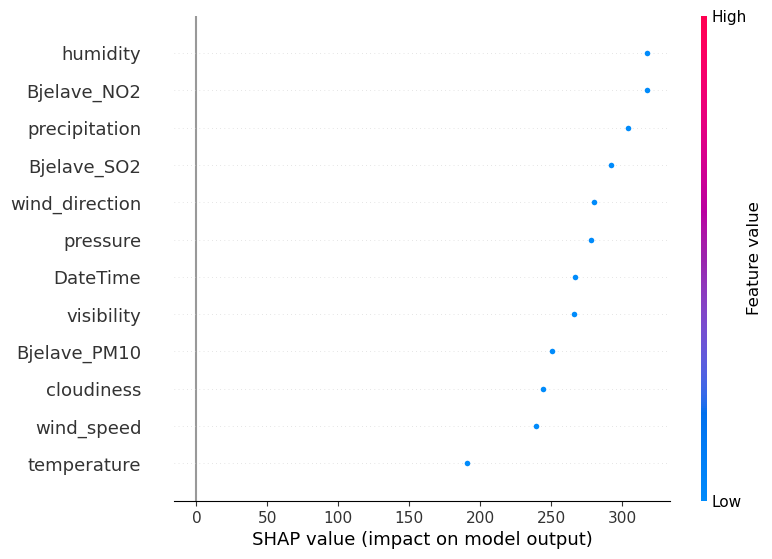

In [158]:
shap.plots.beeswarm(explainer_day45_combined_ws_sixty, max_display=len(custom_feature_names))


In [124]:
shap_values_day55_combined_ws_sixty = explainer_day_combined_ws_sixty.shap_values(day55_to_explain_ws_sixty)


100%|██████████| 1/1 [04:12<00:00, 252.59s/it]


In [125]:
print(day55_to_explain_ws_sixty.shape)  # treba biti (1, 12)
print(np.array(shap_values_day55_combined_ws_sixty).shape)

(1, 12)
(1, 12)


In [123]:
print(day30_to_explain_ws_thirty.shape)
print(np.array(shap_values_day30_combined_ws_sixty).shape)

(1, 12)
(1, 12)


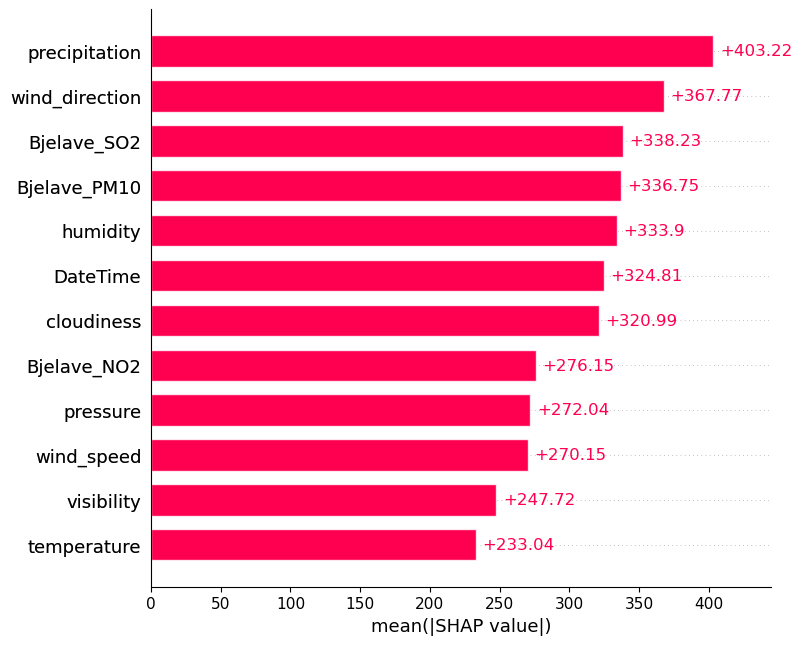

In [126]:
explainer_day55_combined_ws_sixty = shap.Explanation(
    values=shap_values_day55_combined_ws_sixty,
    base_values=np.array([explainer_day_combined_ws_sixty.expected_value] * len(shap_values_day55_combined_ws_sixty)),
    data=day55_to_explain_ws_sixty.values,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_day55_combined_ws_sixty, max_display=len(custom_feature_names))

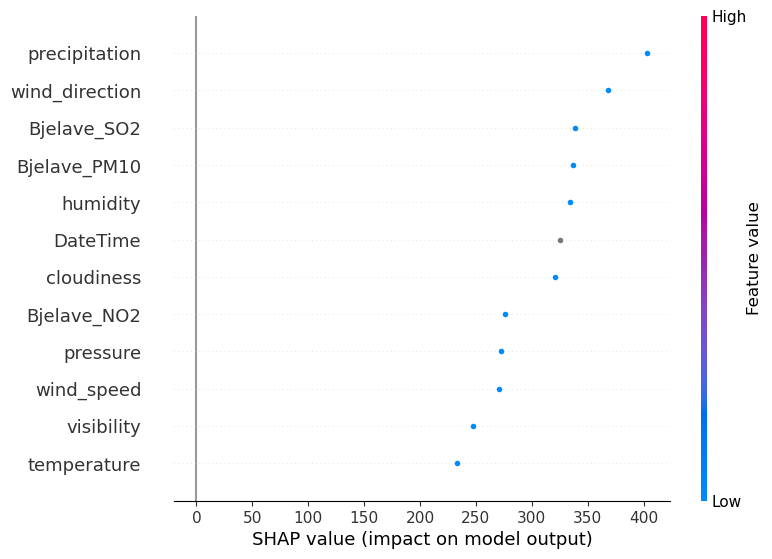

In [159]:
shap.plots.beeswarm(explainer_day55_combined_ws_sixty, max_display=len(custom_feature_names))


In [127]:
print(shap_values_day55_combined_ws_sixty)

[[324.80955445 270.15435472 367.76755277 403.2235495  272.04233661
  233.04291437 333.89610992 247.7164906  320.98928269 336.7532247
  338.23078723 276.15315114]]


In [129]:
shap_values_day60_combined_ws_sixty = explainer_day_combined_ws_sixty.shap_values(day60_to_explain_ws_sixty)


100%|██████████| 1/1 [04:24<00:00, 264.55s/it]


In [130]:
print(day60_to_explain_ws_sixty.shape)
print(np.array(shap_values_day60_combined_ws_sixty).shape)

(1, 12)
(1, 12)


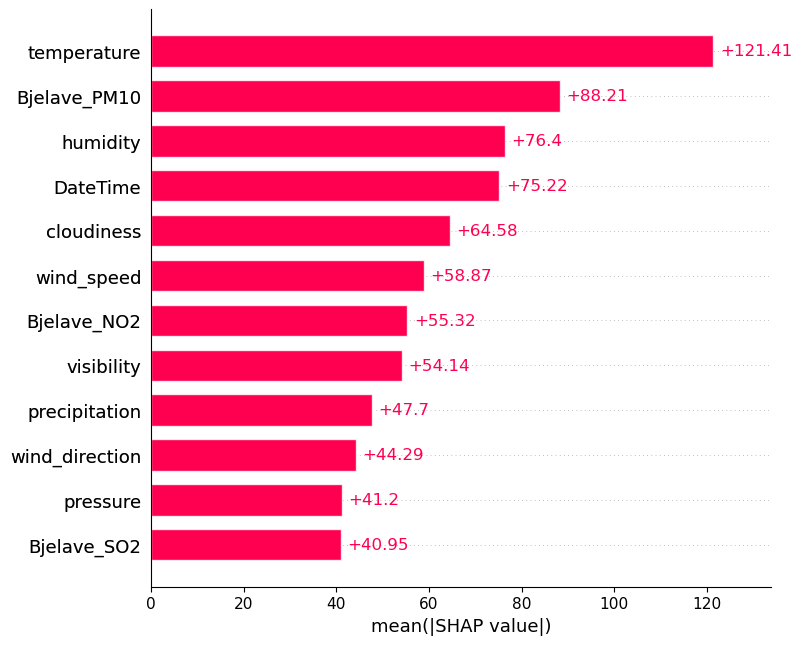

In [132]:
explainer_day60_combined_ws_sixty = shap.Explanation(
    values=shap_values_day60_combined_ws_sixty,
    base_values=np.array([explainer_day_combined_ws_sixty.expected_value] * len(shap_values_day60_combined_ws_sixty)),
    data=day60_to_explain_ws_sixty.values,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_day60_combined_ws_sixty, max_display=len(custom_feature_names))

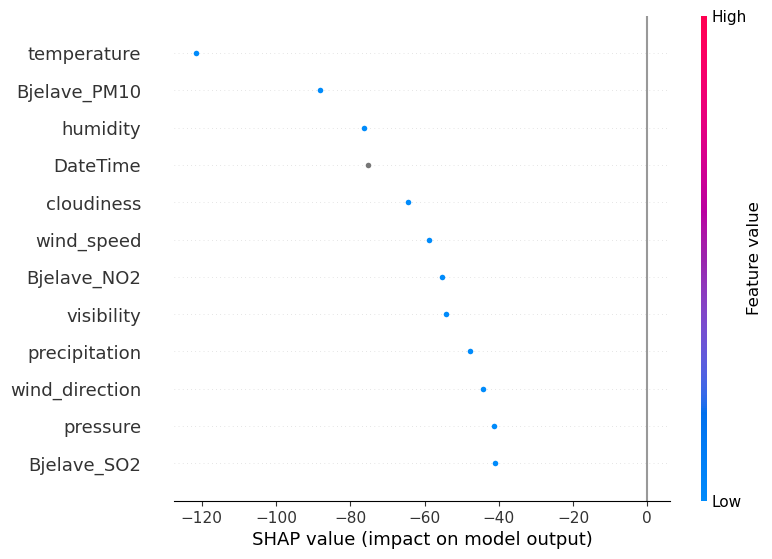

In [160]:
shap.plots.beeswarm(explainer_day60_combined_ws_sixty, max_display=len(custom_feature_names))


In [133]:
print(shap_values_day60_combined_ws_sixty)


[[ -75.21502317  -58.87084078  -44.28976003  -47.69679319  -41.20180694
  -121.41383101  -76.39798161  -54.14084053  -64.5763483   -88.2059213
   -40.95115671  -55.31941305]]


# SHAP Analysis of Selected Prediction Days in Facebook Prophet Model [WINDOW SIZE=30]


In [ ]:
#day20_to_explain_ws_thirty = data_combined_to_explain_ws_thirty.iloc[19]
#day30_to_explain_ws_thirty = data_combined_to_explain_ws_thirty.iloc[29]

In [145]:
explainer_day_combined_ws_thirty = shap.KernelExplainer(prophet_predict_ws_thirty_for_shap_combined, background_data_combined_ws_thirty)

In [146]:
shap_values_day20_combined_ws_thirty = explainer_day_combined_ws_thirty.shap_values(day20_to_explain_ws_thirty)

100%|██████████| 1/1 [06:17<00:00, 377.16s/it]


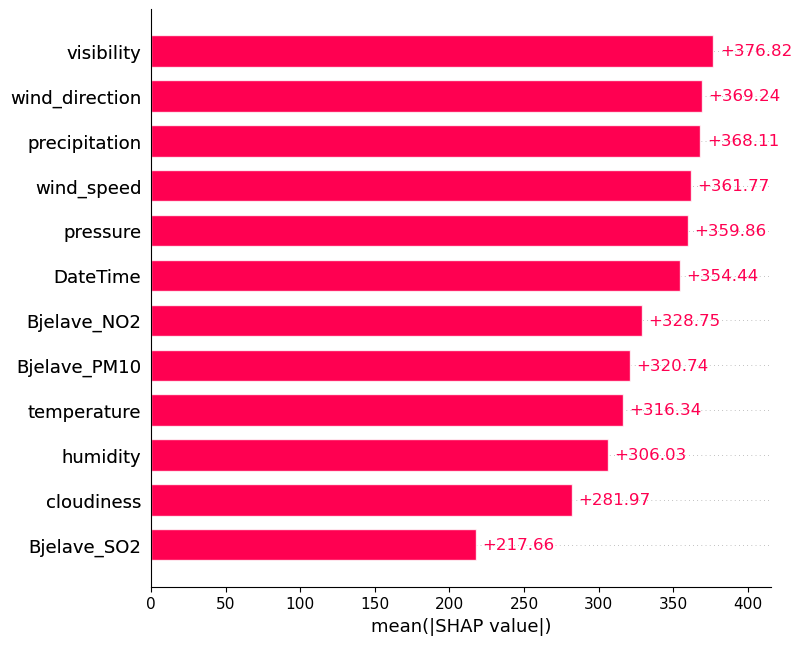

In [150]:
explainer_day20_combined_ws_thirty = shap.Explanation(
    values=shap_values_day20_combined_ws_thirty,
    base_values=np.array([explainer_day_combined_ws_thirty.expected_value] * len(shap_values_day20_combined_ws_thirty)),
    data=day20_to_explain_ws_thirty.values,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_day20_combined_ws_thirty, max_display=len(custom_feature_names))

In [148]:
print(shap_values_day20_combined_ws_thirty)

[[354.43975654 361.77066449 369.24331949 368.11430331 359.85516731
  316.33987735 306.03055412 376.81503465 281.97043223 320.74489219
  217.66421416 328.74662583]]


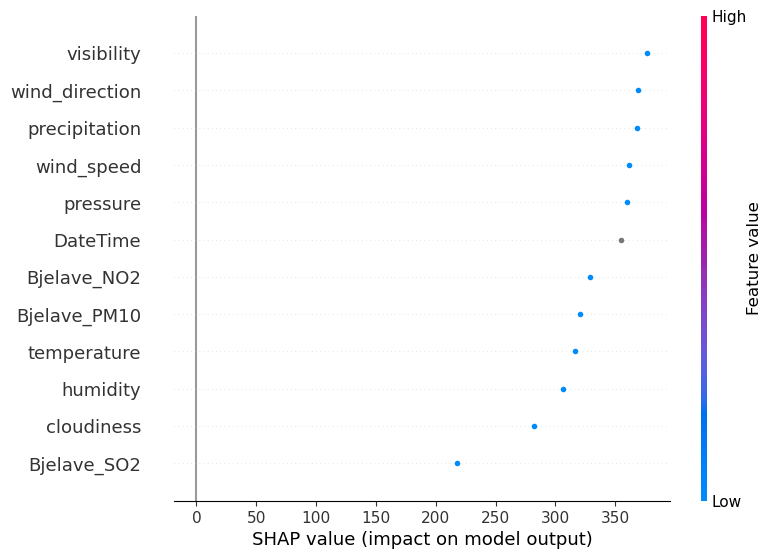

In [154]:
shap.plots.beeswarm(explainer_day20_combined_ws_thirty, max_display=len(custom_feature_names))


In [73]:
shap_values_day30_combined_ws_thirty = explainer_day_combined_ws_thirty.shap_values(day30_to_explain_ws_thirty)

100%|██████████| 1/1 [04:18<00:00, 258.77s/it]


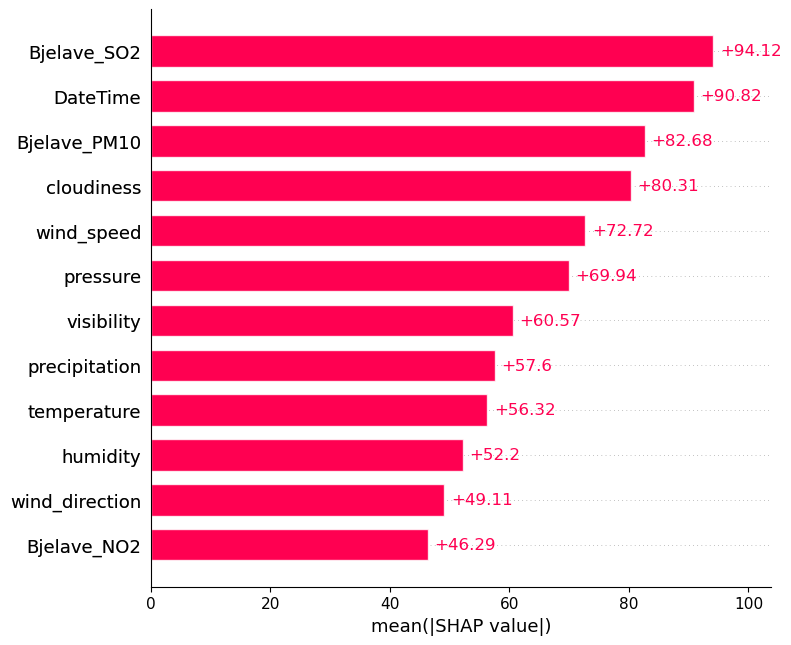

In [152]:
explainer_day30_combined_ws_thirty = shap.Explanation(
    values=shap_values_day30_combined_ws_thirty,
    base_values=np.array([explainer_day_combined_ws_thirty.expected_value] * len(shap_values_day30_combined_ws_thirty)),
    data=day30_to_explain_ws_thirty.values,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_day30_combined_ws_thirty, max_display=len(custom_feature_names))

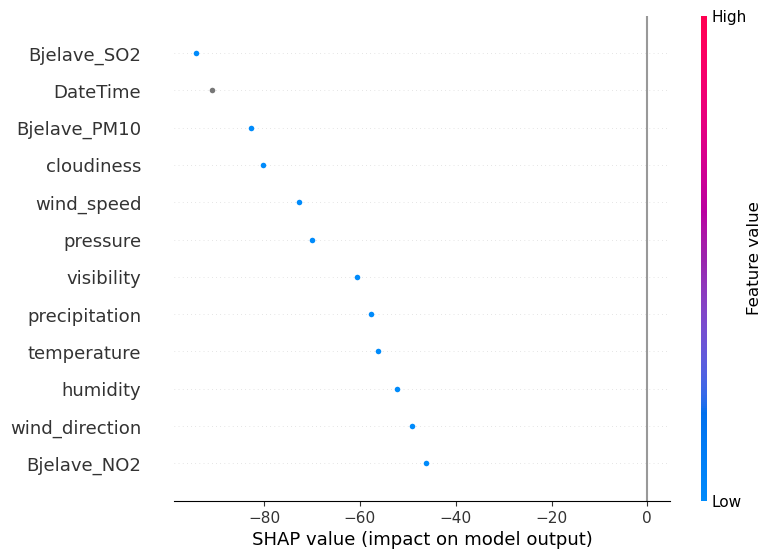

In [153]:
shap.plots.beeswarm(explainer_day30_combined_ws_thirty, max_display=len(custom_feature_names))


# SHAP Analysis of Selected Forecast Horizons in Facebook Prophet Model [WINDOW SIZE=60]


In [ ]:
explainer_data_combined_ws_sixty = shap.KernelExplainer(prophet_predict_ws_sixty_for_shap_combined, background_data_combined_ws_sixty)
shap_values_data_combined_ws_sixty = explainer_data_combined_ws_sixty.shap_values(data_combined_to_explain_ws_sixty)

In [ ]:
explainer_data_combined_ws_sixty_mod = shap.Explanation(
    values=shap_values_data_combined_ws_sixty,
    base_values=np.array([explainer_data_combined_ws_sixty.expected_value] * len(shap_values_data_combined_ws_sixty)),
    data=data_combined_to_explain_ws_sixty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_sixty_mod, max_display=len(custom_feature_names))

In [ ]:
shap.plots.beeswarm(explainer_data_combined_ws_sixty_mod, max_display=len(custom_feature_names))

In [ ]:
df1 = pd.DataFrame({
    "Index": list(range(len(background_data_combined_ws_sixty.columns))),
    "Background Columns": background_data_combined_ws_sixty.columns
})
df2 = pd.DataFrame({
    "Index": list(range(len(data_combined_to_explain_ws_sixty.columns))),
    "To Explain Columns": data_combined_to_explain_ws_sixty.columns
})
combined = pd.merge(df1, df2, on="Index", how="outer")
print(combined)

In [ ]:
custom_feature_names_trimmed = custom_feature_names[1:]
custom_feature_names_trimmed[0]

# SHAP Analysis of Selected Forecast Horizons in Facebook Prophet Model [WINDOW SIZE=90]

In [ ]:
explainer_data_combined_ws_ninety = shap.KernelExplainer(prophet_predict_ws_ninety_for_shap_combined, background_data_combined_ws_ninety)
shap_values_data_combined_ws_ninety = explainer_data_combined_ws_ninety.shap_values(data_combined_to_explain_ws_ninety)

In [ ]:
explainer_data_combined_ws_ninety_mod = shap.Explanation(
    values=shap_values_data_combined_ws_ninety,
    base_values=np.array([explainer_data_combined_ws_ninety.expected_value] * len(shap_values_data_combined_ws_ninety)),
    data=data_combined_to_explain_ws_ninety,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_ninety_mod, max_display=len(custom_feature_names))

In [ ]:
shap.plots.beeswarm(explainer_data_combined_ws_ninety_mod, max_display=len(custom_feature_names))

In [ ]:
explainer_data_combined_ws_oneHundredEighty = shap.KernelExplainer(prophet_predict_ws_oneHundredEighty_for_shap_combined, background_data_combined_ws_oneHundredEighty)
shap_values_data_combined_ws_oneHundredEighty = explainer_data_combined_ws_oneHundredEighty.shap_values(data_combined_to_explain_ws_oneHundredEighty)

In [ ]:
explainer_data_combined_ws_oneHundredEighty_mod = shap.Explanation(
    values=shap_values_data_combined_ws_oneHundredEighty,
    base_values=np.array([explainer_data_combined_ws_oneHundredEighty.expected_value] * len(shap_values_data_combined_ws_oneHundredEighty)),
    data=data_combined_to_explain_ws_oneHundredEighty,
    feature_names=custom_feature_names
)
shap.plots.bar(explainer_data_combined_ws_oneHundredEighty_mod, max_display=len(custom_feature_names))

In [ ]:
shap.plots.beeswarm(explainer_data_combined_ws_oneHundredEighty_mod, max_display=len(custom_feature_names))

# Dependence Plots for Window Size 60 (FB Prophet Model)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=1
)

In [ ]:
shap.dependence_plot(
    ind=1,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=2,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=2
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=3
)

In [ ]:
shap.dependence_plot(
    ind=3,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=4
)

In [ ]:
shap.dependence_plot(
    ind=4,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=5
)

In [ ]:
shap.dependence_plot(
    ind=5,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=6
)

In [ ]:
shap.dependence_plot(
    ind=6,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=7
)

In [ ]:
shap.dependence_plot(
    ind=7,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=9
)

In [ ]:
shap.dependence_plot(
    ind=9,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=10
)

In [ ]:
shap.dependence_plot(
    ind=10,
    shap_values=shap_values_data_combined_ws_sixty[:, 1:],
    features=data_combined_to_explain_ws_sixty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

# Dependence Plots for Window Size 90 (FB Prophet Model)


In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=10,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=10
)

In [ ]:
shap.dependence_plot(
    ind=9,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=9
)

In [ ]:
shap.dependence_plot(
    ind=7,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=7
)

In [ ]:
shap.dependence_plot(
    ind=6,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=6
)

In [ ]:
shap.dependence_plot(
    ind=5,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=5
)

In [ ]:
shap.dependence_plot(
    ind=4,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=4
)

In [ ]:
shap.dependence_plot(
    ind=3,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=3
)

In [ ]:
shap.dependence_plot(
    ind=2,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=2
)

In [ ]:
shap.dependence_plot(
    ind=1,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_ninety[:, 1:],
    features=data_combined_to_explain_ws_ninety.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=1
)

# Dependence Plots for Window Size 30 (FB Prophet Model)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=1
)

In [ ]:
shap.dependence_plot(
    ind=1,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=2
)

In [ ]:
shap.dependence_plot(
    ind=2,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=3
)

In [ ]:
shap.dependence_plot(
    ind=3,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=4
)

In [ ]:
shap.dependence_plot(
    ind=4,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=5
)

In [ ]:
shap.dependence_plot(
    ind=5,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=6
)

In [ ]:
shap.dependence_plot(
    ind=6,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=7
)

In [ ]:
shap.dependence_plot(
    ind=7,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=9
)

In [ ]:
shap.dependence_plot(
    ind=9,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)

In [ ]:
shap.dependence_plot(
    ind=8,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=10
)

In [ ]:
shap.dependence_plot(
    ind=10,
    shap_values=shap_values_data_combined_ws_thirty[:, 1:],
    features=data_combined_to_explain_ws_thirty.iloc[:, 1:],
    feature_names=custom_feature_names_trimmed,
    interaction_index=8
)